In [ ]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import warnings

warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# Load Dataset

df = pd.read_csv("../dataset/Womens Clothing E-Commerce Reviews.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
# Dataset Information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


In [5]:
# Check Missing Values

df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [6]:
# Dataset Shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 23486
Columns: 11


In [7]:
# Display Column Names

print(df.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')


In [8]:
# Select Required Columns

df = df[['Clothing ID',
         'Age',
         'Rating',
         'Review Text',
         'Recommended IND']]

df.head()

,Clothing ID,Age,Rating,Review Text,Recommended IND
0,767,33,4,Absolutely wonderful - silky and sexy and comf...,1
1,1080,34,5,Love this dress! it's sooo pretty. i happene...,1
2,1077,60,3,I had such high hopes for this dress and reall...,0
3,1049,50,5,"I love, love, love this jumpsuit. it's fun, fl...",1
4,847,47,5,This shirt is very flattering to all due to th...,1


In [9]:
# Remove Missing Review Text

df = df.dropna(subset=['Review Text'])

print("Dataset Shape:", df.shape)

Dataset Shape: (22641, 5)


In [10]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [11]:
df['Sentiment'] = df['Review Text'].apply(get_sentiment)

df.head()

,Clothing ID,Age,Rating,Review Text,Recommended IND,Sentiment
0,767,33,4,Absolutely wonderful - silky and sexy and comf...,1,Positive
1,1080,34,5,Love this dress! it's sooo pretty. i happene...,1,Positive
2,1077,60,3,I had such high hopes for this dress and reall...,0,Positive
3,1049,50,5,"I love, love, love this jumpsuit. it's fun, fl...",1,Positive
4,847,47,5,This shirt is very flattering to all due to th...,1,Positive


In [12]:
df['Sentiment'].value_counts()

Sentiment
Positive    21227
Negative     1315
Neutral        99
Name: count, dtype: int64

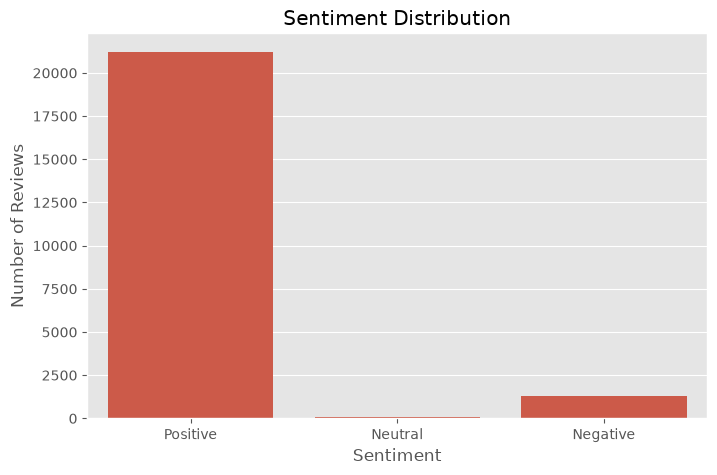

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("../images/sentiment_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

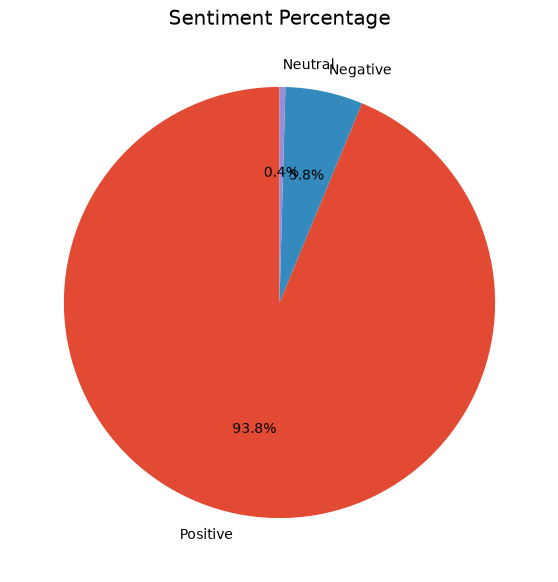

In [14]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sentiment Percentage")

plt.savefig("../images/sentiment_pie_chart.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

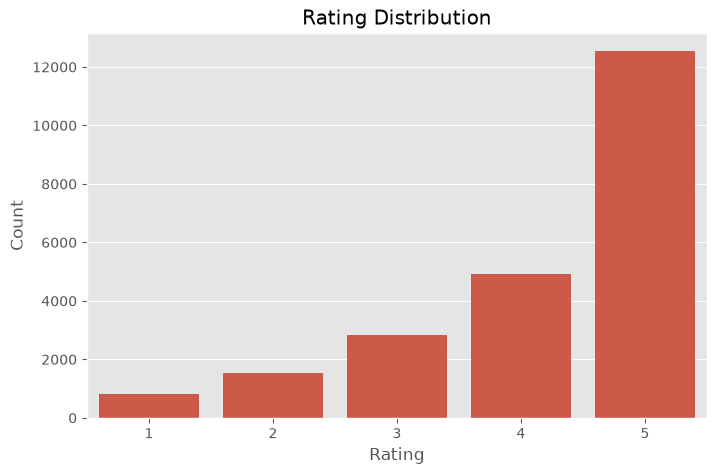

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Rating')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("../images/rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

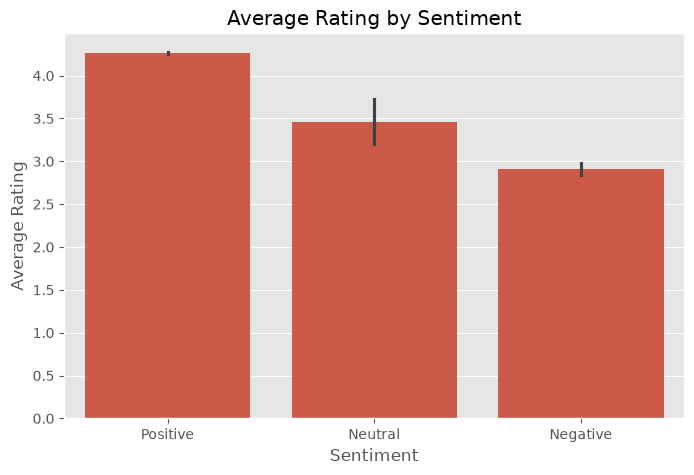

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Sentiment',
    y='Rating',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")

plt.savefig("../images/average_rating_sentiment.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

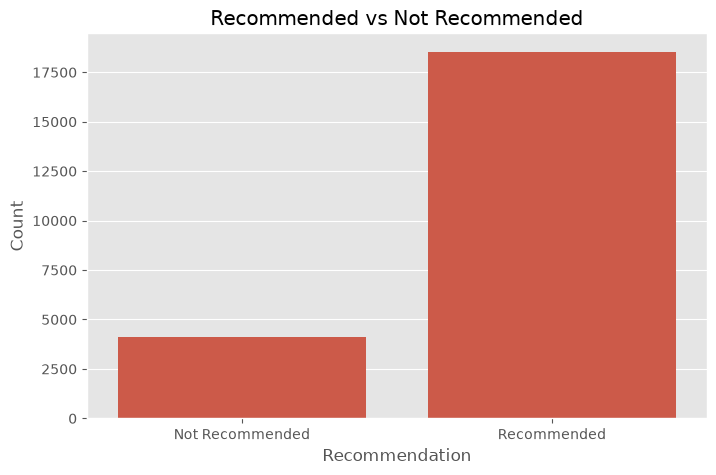

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Recommended IND'
)

plt.title("Recommended vs Not Recommended")
plt.xlabel("Recommendation")
plt.ylabel("Count")

plt.xticks([0,1], ["Not Recommended", "Recommended"])

plt.savefig("../images/recommendation_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [18]:
print("Business Insights")
print("-"*50)

print(f"Total Reviews: {len(df)}")

print(f"Average Rating: {df['Rating'].mean():.2f}")

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

print("\nRecommendation Percentage:")
print(df['Recommended IND'].value_counts(normalize=True)*100)

Business Insights
--------------------------------------------------
Total Reviews: 22641
Average Rating: 4.18

Sentiment Distribution:
Sentiment
Positive    21227
Negative     1315
Neutral        99
Name: count, dtype: int64

Recommendation Percentage:
Recommended IND
1    81.886842
0    18.113158
Name: proportion, dtype: float64
